In [2]:
import random
import numpy as np

In [3]:
def square_wave(start, length, magnitude):
    vals = np.zeros(1440)
    size = magnitude / length
    for i in range(length):
        vals[start+i] = size + 0.1 * np.random.uniform(-np.abs(size), np.abs(size))
    return vals

In [4]:

def spike():
    # First we create an empty array of the correct length 
    ep = 1e-6
    spikes = np.zeros(1440)

    # We model the dawn phenomenon with an average spike of 20 mg/dl
    dp = random.randint(180, 480)

    # Random scaling 
    dpscale = random.uniform(ep, 2)
    spikes[dp] = dpscale * 20

    # We model breakfast with a single spike of average 40
    bs = random.randint(420, 540)
    bscale = random.uniform(ep, 2)
    bs_magnitude = bscale * 40
    bs_length = random.randint(6, 12)
    spikes += square_wave(bs, bs_length, bs_magnitude)

    # We next model lunch with a single spike of average 60
    ls = random.randint(660, 780)
    lscale = random.uniform(ep, 2)
    l_magnitude = lscale * 60
    l_length = random.randint(6, 24)
    spikes += square_wave(ls, l_length, l_magnitude)

    # We model dinner with two spikes 60 and 20 seperated by 20 minutes
    ds = random.randint(1080, 1200)
    dscale = random.uniform(ep, 2)
    d_magnitude = dscale * 80
    d_length = random.randint(6, 36)
    spikes += square_wave(ds, d_length, d_magnitude)

    # We add a snack
    ss = random.randint(360, 1380)
    sscale = random.uniform(ep, 2)
    ss_magnitude = sscale * 20
    ss_length = random.randint(6, 9)
    spikes += square_wave(ss, ss_length, ss_magnitude)

    # Now we add exercise
    es = random.randint(360, 1380)
    escale = random.uniform(ep, 2)
    es_magnitude = -escale* 35
    es_length = random.randint(1, 12)
    spikes += square_wave(es, es_length, es_magnitude)


    var = np.random.uniform(.6, 1.4)
    spikes *= var
    
    return spikes

In [5]:
spikes = spike()

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
def simulate(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=6):
    def fun(t, x):
        xerr = x - np.array([target, base_insulin])
     
        dxdt = np.array([[-a, -b], [d, -c]]) @ xerr

        #Make sure we don't get negative insulin
        if x[1] <= 0 and dxdt[1] < 0:
            dxdt[1] = 0
        return dxdt
    current = starting
    t_hist = []
    y_hist = []
    readings = [starting.copy()]
    for t in range(0, t_steps, dt):
        current[0] += np.sum(spikes[t:t+dt])
        # Time delay of cgm
        if step_delay == 0:
            delayed = current.copy()
        elif len(readings) > step_delay:
            delayed = readings[-step_delay] 
        else:
            delayed = readings[0] 

        sol = solve_ivp(fun=fun, t_span=(t, t+dt), y0=current)
        current = np.maximum(0, sol.y[:, -1])
        readings.append(current.copy())
        t_hist.append(sol.t)
        y_hist.append(sol.y)
    return np.concatenate(t_hist), np.concatenate(y_hist, axis=1)



t_steps = 1440
dt = 5
starting = np.array([85, 15])
a = 0.1
b = 0.01
c = 0.05
d = 0.0
glucose_penalty = 10
insulin_penalty = 5
controller_penalty = 100
derivitive_penalty = 2
step_delay = 0


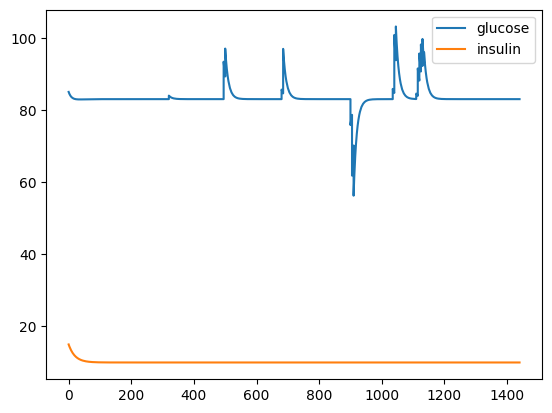

In [7]:
import matplotlib.pyplot as plt
t_steps = 1440
dt = 5
starting = np.array([85, 15])
a = 0.1
b = 0.01
c = 0.05
d = 0.0
glucose_penalty = 10
insulin_penalty = 5
controller_penalty = 100
derivitive_penalty = 2
step_delay = 0
t, states = simulate(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=step_delay)
plt.plot(t, states[0], label='glucose')
plt.plot(t, states[1], label='insulin')
plt.legend()
plt.show()